In [1]:
import sys
import torch
import functools
import matplotlib.pyplot as plt
import argparse, yaml, os
import torch.optim.lr_scheduler as lr_scheduler
import torchvision.transforms as transforms
import seaborn as sns
import pandas as pd
import tqdm
import glob

from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from types import SimpleNamespace

from IPython.display import clear_output

sys.path.append('/om2/user/jmhicks/projects/TextureStreaming/code/')

from chexture_choolbox.auditorytexture.statistics_sets import (
    STAT_SET_FULL_MCDERMOTTSIMONCELLI as statistics_dict
)
from chexture_choolbox.auditorytexture.texture_model import TextureModel
from chexture_choolbox.auditorytexture.helpers import FlattenStats
from texture_prior.params import model_params as model_params_tm
from texture_prior.params import statistics_set, texture_dataset
from texture_prior.utils import path

sys.path.append('../utls/')
sys.path.append('../src/model/')
sys.path.append("/om2/user/bjmedina/auditory-memory/memory/")
import DistanceMemoryModel
import encoders

from utls.loading import load_results, load_results_with_isi0_exclusion, load_results_with_isi0_dprime_exclusion, move_sequences_to_used, load_results_with_exclusion
from utls.dprime import recompute_dprime_by_isi_per_subject
from utls.reliability import compute_itemwise_split_half_reliability
from utls.plotting import plot_dprime_by_isi, plot_itemwise_split_half_scatter_df, ensure_dir


sounds_list = glob.glob("/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_atexts_2025/*wav")
device = 'cuda'
# get soem textures
pc_dims = 256

pc_texture_model = encoders.AudioTextureEncoderPCA(
    statistics_dict=statistics_set.statistics,
    pc_dims=pc_dims,
    model_params=model_params_tm,
    sr=20000,
    rms_level=0.05,
    duration=2.0,
    device=device
)

def compute_likelihood(score_model, input_stats, ckpt):
    """Computing the actual "prior" value
    If the score function can be treated as the vector field govering the temporal evolution
    of $x_t$ then we can integrate the ODE and apply a change of basis to evaluate the prior
    """
    score_model.load_state_dict(torch.load(ckpt))
    input_stats = input_stats.to(device)

    _, bpd = ode_likelihood(input_stats, score_model, marginal_prob_std_fn,
                            diffusion_coeff_fn,
                            input_stats.shape[0], device=device, eps=1e-5)
    
    return bpd

def parse(d):
  x = SimpleNamespace()
  _ = [setattr(x, k, parse(v)) if isinstance(v, dict) else setattr(x, k, v) for k, v in d.items() ]    
  return x

In [2]:
# parser.add_argument('--config', type=str, required=True, help='model + data configuration')
# parser.add_argument('--train', action='store_true', help='train the score-based model')
# parser.add_argument('--sample', action='store_true', help='sample from a trained model')
# parser.add_argument('--likelihood_eval', action='store_true', help='evaluate the data likelihood')
# parser.add_argument('--restart', action='store_true')
# parser.add_argument('--mode', type=str, default='textures', choices=['textures', 'mixtures'])

# sys.path.append('/om2/user/lakshmin/audio-prior/')
# from models import ScoreNetAudio, ScoreNetTexture1D, ScoreNetAudioV2
# from utils import synthesis, projection, audio
# from utils.sde_utils import *

import sys
import importlib.util
import os

# Add the new path
audio_prior_path = '/om2/user/lakshmin/audio-prior/'
sys.path.insert(0, audio_prior_path)  # insert at front of sys.path

from models import ScoreNetAudio, ScoreNetTexture1D, ScoreNetAudioV2
from utils import synthesis, projection, audio
from utils.sde_utils import *

config = "/om2/user/bjmedina/auditory-memory/memory/assets/bryan.yaml"
train = False
sample = False
likelihood_eval = True
restart = False
mode = 'textures'

device = 'cuda'

In [78]:
df = yaml.safe_load(open(config))
cfg = parse(df)

print(cfg.data)
print(cfg.data.var_scale)

namespace(data_root='/om2/user/lakshmin/audio-prior/assets/texture_statistics_4096texturePCs.pt', data_mix_root='/om2/user/lakshmin/audio-prior/assets/mixture_statistics_4096PCs.pt', n_pcs=256, var_scale=False)
False


In [4]:
score_model = torch.nn.DataParallel(
                    ScoreNetAudioV2(
                        marginal_prob_std=marginal_prob_std_fn, 
                        channels=cfg.model.channels, 
                        embed_dim=cfg.model.embed_dim
                        )
                    )

score_model = score_model.to(device)

ckpt_path = cfg.model.ckpt_path.format(cfg.data.n_pcs, mode)
ckpt_path = "/om2/user/lakshmin/audio-prior/" + ckpt_path
if 'SLURM_RESTART_COUNT' in os.environ.keys() or restart:
    score_model.load_state_dict(torch.load(ckpt_path))

print(ckpt_path)

/om2/user/lakshmin/audio-prior/ckpts/texture_diffusion2D_prior_256pcs_mode_textures.pth


In [5]:
# from dataloader import TextureStatsDataset
# texture_dataset = TextureStatsDataset(
#                 config=cfg,                        
#                 device=device
#             )
# x = texture_dataset.get_random_batch(1024)


sounds_to_test = 2000
effective_num_sounds = sounds_to_test

rep = []

t_something = 0.01

exp_sounds = glob.glob("/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_atexts_2025/*wav")

for sound in exp_sounds:
    vec = pc_texture_model(sound)

    try:
        if not torch.is_tensor(vec):
            vec = torch.tensor(vec)  # convert if it's a numpy array
        rep.append(vec)

        t = torch.tensor([t_something], device=vec.device).float()

        

        score = score_model(vec.view(1, 1, 1, 256), t)

        # 2. Flatten for norm computation per sample
        score_flat = score.view(score.size(0), -1)  # [B, 256]
        
        # 3. Normalize: divide by norm per sample
        norms = score_flat.norm(p=2, dim=1, keepdim=True) + 1e-8  # prevent division by zero
        unit_score_flat = score_flat / norms  # [B, 256]

        #print(unit_score_flat)
        
        # 4. Reshape back to original format
        unit_score = unit_score_flat.view_as(score)  # [B, 1, 1, 256]

        #input()
        #clear_output(wait=True)

    
    except Exception as e:
        print(e)
        effective_num_sounds -= 1


# Now stack all into one tensor
x = torch.stack(rep).float()  # shape: [N, ...]
x = x.view(len(exp_sounds), 1, 1, 256)

bpd_textures = compute_likelihood(score_model, input_stats=x, ckpt=ckpt_path)

x_numpy = x.squeeze(1).squeeze(1).detach().cpu().numpy()


In [76]:
x_orig = x_numpy
idx = np.random.random_integers(0, x_orig.shape[0]-1, cfg.sample.sample_batch_size)
x_orig = x_orig[idx]

sample_batch_size = cfg.sample.sample_batch_size
sampler = Euler_Maruyama_sampler_1d if cfg.model.use_single_dim_conv else Euler_Maruyama_sampler
init_dims = [1, cfg.data.n_pcs] if cfg.model.use_single_dim_conv else [1, 1, cfg.data.n_pcs]

# generate samples using the specified sampler.
print(cfg.sample.num_steps)
samples, trajectory = sampler(
                        score_model,
                        marginal_prob_std_fn,
                        diffusion_coeff_fn,
                        num_steps=cfg.sample.num_steps,
                        batch_size=sample_batch_size,
                        device=device,
                        init_dims=init_dims)

samples = samples.squeeze().detach().cpu().numpy()


/tmp/ipykernel_437765/4143148433.py:2: DeprecationWarning: This function is deprecated. Please call randint(0, 79 + 1) instead
  idx = np.random.random_integers(0, x_orig.shape[0]-1, cfg.sample.sample_batch_size)


2500


100%|██████████| 2500/2500 [01:20<00:00, 30.91it/s]


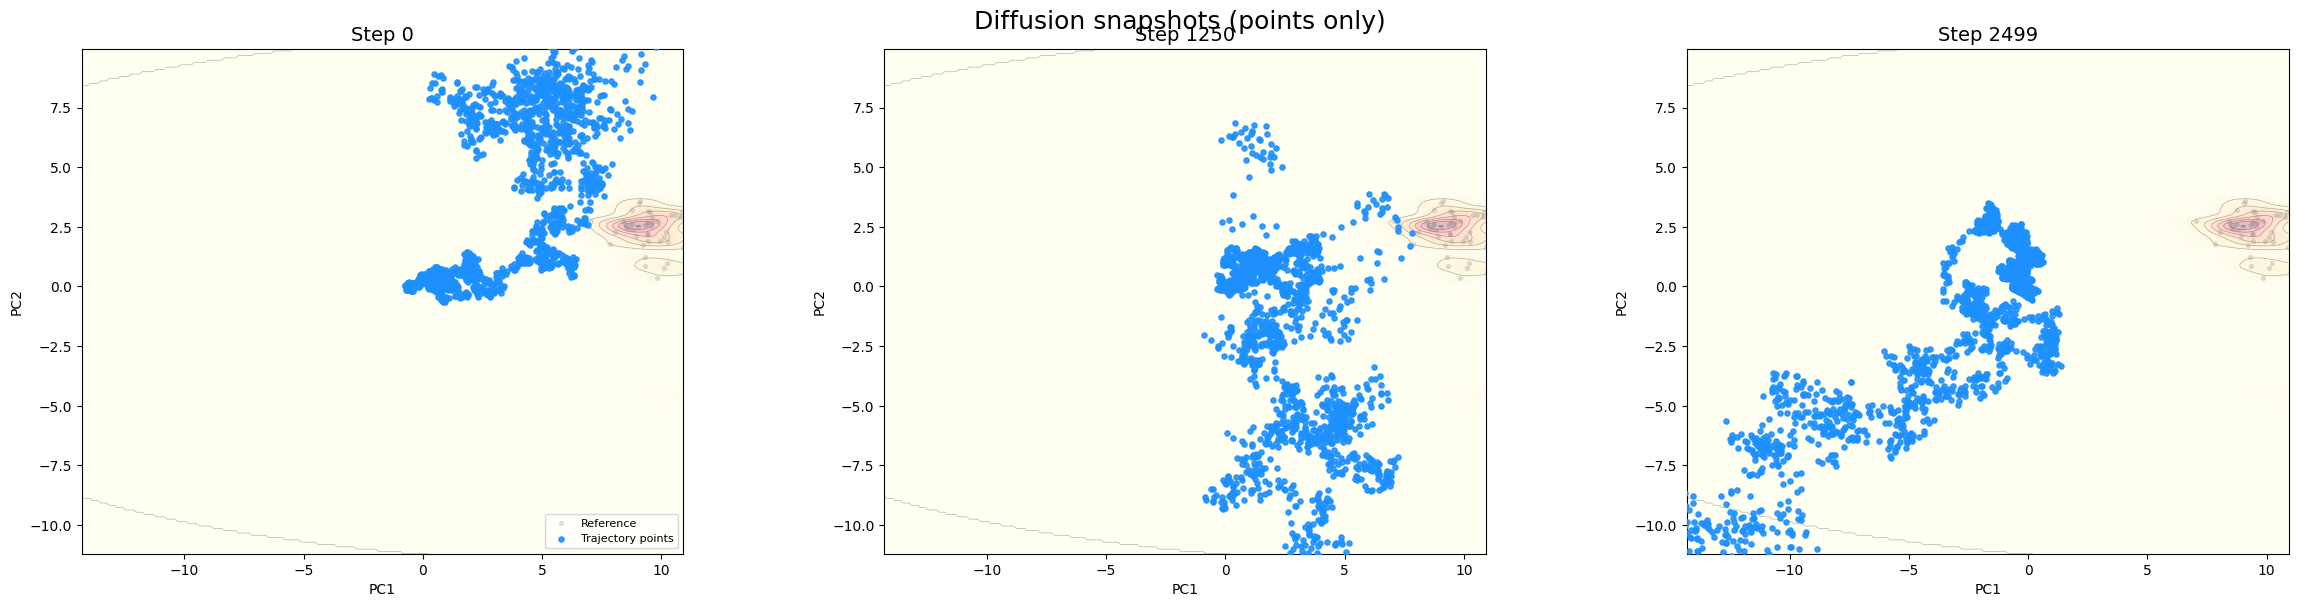

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# steps to show
T_to_check = [0, cfg.sample.num_steps // 2, cfg.sample.num_steps - 1]

# stack trajectory list -> (N, T, D)
traj_np = np.stack([
    (tr.detach().cpu().numpy() if hasattr(tr, "detach") else np.asarray(tr)).squeeze(1).squeeze(1)
    for tr in trajectory
])
N, T, D = traj_np.shape
traj_2d = traj_np[:, :, :2]      # first two PCA dims
Z_train = x_numpy[:, :2]

# clip step indices to valid range
T_to_check = [min(max(0, t), T - 1) for t in T_to_check]

# broad fixed bounds from both train + shown trajectory points
sel_pts = traj_2d[:, T_to_check, :].reshape(-1, 2)
all_pts = np.vstack([Z_train, sel_pts])
x_min, x_max = np.percentile(all_pts[:, 0], [0.5, 99.5])
y_min, y_max = np.percentile(all_pts[:, 1], [0.5, 99.5])

# KDE background (train only)
G0, G1 = np.meshgrid(np.linspace(x_min, x_max, 220), np.linspace(y_min, y_max, 220))
Q = gaussian_kde(Z_train.T, bw_method=0.15)(np.vstack([G0.ravel(), G1.ravel()])).reshape(G0.shape)

fig, axes = plt.subplots(1, len(T_to_check), figsize=(24, 5.8), constrained_layout=True)
if len(T_to_check) == 1:
    axes = [axes]

for i, t_idx in enumerate(T_to_check):
    ax = axes[i]
    ax.imshow(Q, origin="lower", cmap="YlOrRd", alpha=0.25, extent=[x_min, x_max, y_min, y_max], aspect="equal")
    ax.contour(G0, G1, Q, levels=8, colors="k", linewidths=0.5, alpha=0.3)

    ax.scatter(Z_train[:, 0], Z_train[:, 1], c="gray", s=8, alpha=0.2, label="Reference", zorder=2)
    ax.scatter(traj_2d[:, t_idx, 0], traj_2d[:, t_idx, 1], c="dodgerblue", s=14, alpha=0.9, label="Trajectory points", zorder=4)

    ax.set_title(f"Step {t_idx}", fontsize=14)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

axes[0].legend(loc="lower right", fontsize=8)
plt.suptitle("Diffusion snapshots (points only)", fontsize=18, y=1.02)
plt.show()


In [79]:
import numpy as np
from scipy.stats import normaltest

traj_np = np.stack([
    (t.detach().cpu().numpy() if hasattr(t, "detach") else np.asarray(t)).squeeze(1).squeeze(1)
    for t in trajectory
])  # (N, T, D)

N, T, D = traj_np.shape
traj2 = traj_np[:, :, :2]
Z = x_numpy[:, :2]
center = np.median(Z, axis=0)

# Dist-to-data-center curve
dist_curve = np.array([
    np.median(np.linalg.norm(traj2[:, t, :] - center, axis=1))
    for t in range(T)
])

print("argmax dist (most noise-like):", int(np.argmax(dist_curve)))
print("argmin dist (most data-like):", int(np.argmin(dist_curve)))
print("dist[0], dist[T-1]:", float(dist_curve[0]), float(dist_curve[-1]))

# Normality tests at first and last stored frames
for t in [0, T-1]:
    p1 = normaltest(traj2[:, t, 0]).pvalue
    p2 = normaltest(traj2[:, t, 1]).pvalue
    print(f"t={t}: p(PC1)={p1:.3g}, p(PC2)={p2:.3g}")


argmax dist (most noise-like): 2243
argmin dist (most data-like): 2605
dist[0], dist[T-1]: 9.501795768737793 13.155213356018066
t=0: p(PC1)=0, p(PC2)=2.63e-226
t=4095: p(PC1)=6.36e-115, p(PC2)=1.12e-26


(2501, 4096, 256)


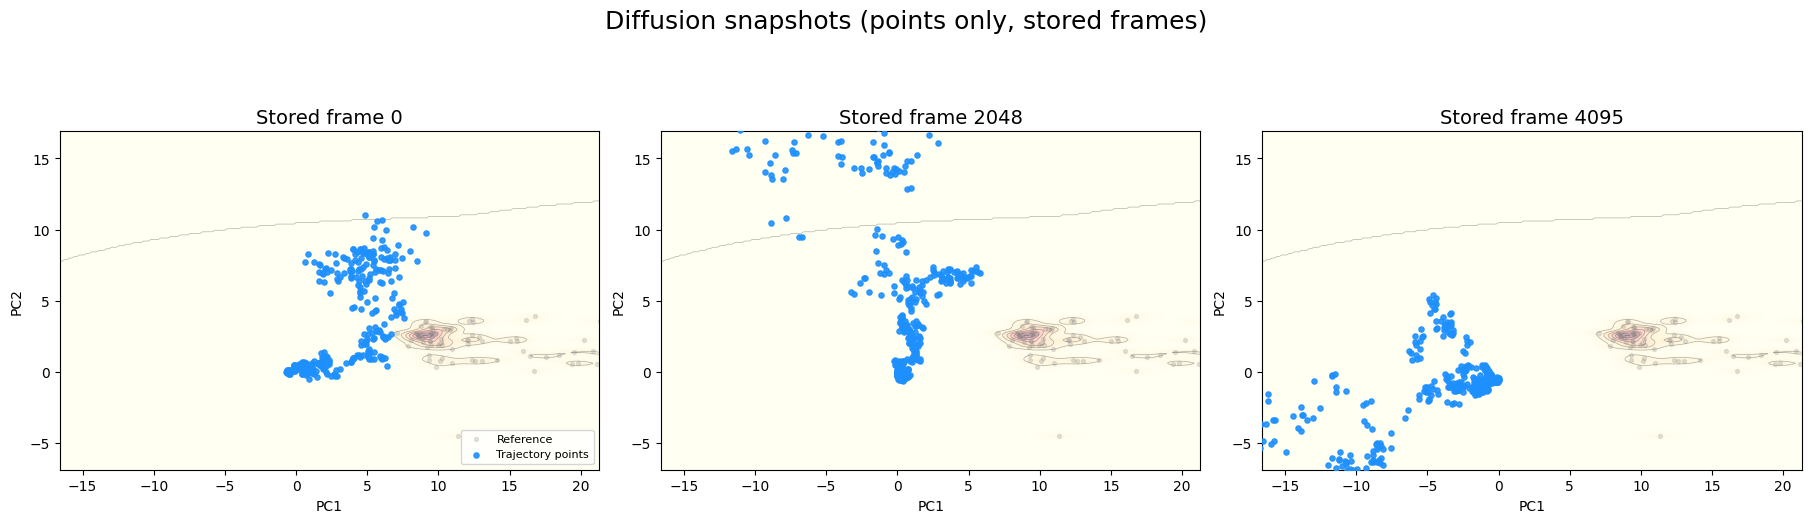

N=2501, stored frames=4096, shown=400
Indices used: first=0, mid=2048, last=4095


In [84]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# --- Convert trajectory list to (N, T_store, D) ---
traj_np = np.stack([
    (tr.detach().cpu().numpy() if hasattr(tr, "detach") else np.asarray(tr)).squeeze(1).squeeze(1)
    for tr in trajectory
])
N, T_store, D = traj_np.shape
print( traj_np.shape)
traj_2d = traj_np[:, :, :2]     # already PCA space
Z_train = x_numpy[:, :2]

# --- Guaranteed frame choices from stored trajectory ---
# (works whether sampler stored num_steps or num_steps+1 frames)
first_t = 0
mid_t = T_store // 2
last_t = T_store - 1
step_indices = [first_t, mid_t, last_t]
step_labels = [f"Stored frame {first_t}", f"Stored frame {mid_t}", f"Stored frame {last_t}"]

# Optional subsample for readability
rng = np.random.default_rng()
num_show = min(400, N)
show_idx = rng.choice(N, size=num_show, replace=False)
traj_show = traj_2d[show_idx]

# --- Plot bounds from BOTH reference + shown trajectory frames ---
sel_pts = traj_show[:, step_indices, :].reshape(-1, 2)
all_pts = np.vstack([Z_train, sel_pts])
x_min, x_max = np.percentile(all_pts[:, 0], [0.5, 99.5])
y_min, y_max = np.percentile(all_pts[:, 1], [0.5, 99.5])

# --- KDE background from reference only ---
grid_size = 220
G0, G1 = np.meshgrid(
    np.linspace(x_min, x_max, grid_size),
    np.linspace(y_min, y_max, grid_size),
)
Q = gaussian_kde(Z_train.T, bw_method=0.15)(np.vstack([G0.ravel(), G1.ravel()])).reshape(G0.shape)

# --- Points-only snapshots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5.6), constrained_layout=True)
extent = [x_min, x_max, y_min, y_max]

for ax, t_idx, title in zip(axes, step_indices, step_labels):
    ax.imshow(Q, origin="lower", cmap="YlOrRd", alpha=0.25, extent=extent, aspect="equal")
    ax.contour(G0, G1, Q, levels=8, colors="k", linewidths=0.5, alpha=0.30)

    ax.scatter(Z_train[:, 0], Z_train[:, 1], c="gray", s=8, alpha=0.20, label="Reference", zorder=2)
    ax.scatter(traj_show[:, t_idx, 0], traj_show[:, t_idx, 1],
               c="dodgerblue", s=14, alpha=0.90, label="Trajectory points", zorder=4)

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

axes[0].legend(loc="lower right", fontsize=8)
plt.suptitle("Diffusion snapshots (points only, stored frames)", fontsize=18, y=1.02)
plt.show()

print(f"N={N}, stored frames={T_store}, shown={num_show}")
print(f"Indices used: first={first_t}, mid={mid_t}, last={last_t}")


In [24]:
traj_show[:, step_i, 0]

(300,)